# Linear and group constraints

A mandate is rarely "optimise freely". You cap single-name concentration, hold sector bands,
keep one group bigger than another, and avoid dust positions. `PortfolioOptimisers.jl` expresses
all of these as **constraints on the `JuMPOptimiser`**, layered on top of whatever
objective and prior you use. This deep dive works through the linear and group constraints —
weight bounds, per-member vs group-sum limits, relative and sum constraints — and shows where
the boundary to mixed-integer constraints (thresholds, cardinality) lies.

The unifying idea is the `AssetSets`: you name assets and groups once, then every
constraint refers to those names. The same `"name op value"` string grammar drives both the
linear constraints here and the views in the [prior examples](../2_moments_priors/06_Entropy_Pooling.md).

> **When to reach for this**
>
> Reach for these whenever a real mandate dictates the shape of the book: a 5% single-name cap,
> a 20% sector ceiling, "healthcare at least as big as energy", "no position under 2%". They
> are convex (except thresholds and cardinality, which need a MIP solver) and compose freely
> with any objective, risk measure, and prior. For *cost*-bearing limits — turnover, fees,
> tracking — see the sibling pages in this group.

In [1]:
using PortfolioOptimisers, CSV, TimeSeries, DataFrames, PrettyTables, Clarabel, StatsPlots,
      GraphRecipes

resfmt = (v, i, j) -> begin
    return if j == 1
        v
    else
        isa(v, AbstractFloat) ? "$(round(v*100, digits=3)) %" : v
    end
end;

## 1. ReturnsResult data

The same S&P 500 slice as the other examples.

In [2]:
X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)
pr = prior(EmpiricalPrior(), rd)

slv = Solver(; name = :clarabel, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))
rf = 4.2 / 100 / 252

0.0001666666666666667

## 2. Naming assets and groups

`AssetSets` maps names to members. The `nx` key holds every asset; the rest are the
groups — here, sectors — that constraints will reference.

In [3]:
sets = AssetSets(;
                 dict = Dict("nx" => rd.nx,
                             "tech" => ["AAPL", "AMD", "MSFT"],
                             "financials" => ["BAC", "JPM"],
                             "energy" => ["CVX", "XOM", "RRC"],
                             "healthcare" => ["JNJ", "LLY", "MRK", "PFE", "UNH"],
                             "staples" => ["KO", "PEP", "PG", "WMT"],
                             "consumer" => ["BBY", "HD"],
                             "industrial" => ["GE"]))

AssetSets
   key ┼ String: "nx"
  ukey ┼ String: "ux"
  dict ┴ Dict{String, Vector{String}}: Dict("nx" => ["AAPL", "AMD", "BAC", "BBY", "CVX", "GE", "HD", "JNJ", "JPM", "KO", "LLY", "MRK", "MSFT", "PEP", "PFE", "PG", "RRC", "UNH", "WMT", "XOM"], "financials" => ["BAC", "JPM"], "industrial" => ["GE"], "tech" => ["AAPL", "AMD", "MSFT"], "healthcare" => ["JNJ", "LLY", "MRK", "PFE", "UNH"], "staples" => ["KO", "PEP", "PG", "WMT"], "energy" => ["CVX", "XOM", "RRC"], "consumer" => ["BBY", "HD"])


Our baseline is an unconstrained maximum-ratio portfolio. On this one-year slice it is starkly
concentrated — it piles into the two sectors with the best realised risk-adjusted return and
ignores the rest. That makes it the perfect punching bag for constraints.

In [4]:
res_base = optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                             opt = JuMPOptimiser(; pe = pr, slv = slv)))

sector_weight(w, g) = sum(w[i] for i in eachindex(w) if rd.nx[i] in sets.dict[g])
sectors = ["tech", "financials", "energy", "healthcare", "staples", "consumer", "industrial"]
pretty_table(DataFrame("Sector" => sectors,
                       "Baseline" => [sector_weight(res_base.w, g) for g in sectors]);
             formatters = [resfmt], title = "Baseline max-ratio: sector exposure")

Baseline max-ratio: sector exposure
┌────────────┬──────────┐
│     Sector │ Baseline │
│     String │  Float64 │
├────────────┼──────────┤
│       tech │    0.0 % │
│ financials │    0.0 % │
│     energy │  34.02 % │
│ healthcare │ 65.979 % │
│    staples │  0.001 % │
│   consumer │    0.0 % │
│ industrial │    0.0 % │
└────────────┴──────────┘


## 3. Weight bounds: capping concentration

The simplest constraint is a per-asset bound through `wb`. A global `WeightBounds` with
`ub = 0.15` forbids any single name from exceeding 15%, which forces the optimiser to hold more
names — the book goes from a couple of positions to spread across the book.

In [5]:
res_cap = optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                            opt = JuMPOptimiser(; pe = pr, slv = slv,
                                                wb = WeightBounds(; lb = 0.0, ub = 0.15))))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        oe ┼ DataType: DataType
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 252×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePreci

## 4. Per-member vs group-sum bounds — an important distinction

There are **two different things** you might mean by "the staples bound". A
`WeightBoundsEstimator` with a group key applies the bound to **each member** of the
group; a `LinearConstraintEstimator` bounds the **group sum**. They are not the same:
with four staples names, `WeightBoundsEstimator(lb = ["staples" => 0.15])` forces *each* of them
to at least 15% — 60% in total — whereas `LinearConstraintEstimator(val = ["staples >= 0.15"])`
asks only that the four *together* reach 15%.

In [6]:
res_member = optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                               opt = JuMPOptimiser(; pe = pr, slv = slv, sets = sets,
                                                   wb = WeightBoundsEstimator(;
                                                                              lb = ["staples" => 0.15]))))
res_groupsum = optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                                 opt = JuMPOptimiser(; pe = pr, slv = slv, sets = sets,
                                                     lcse = LinearConstraintEstimator(;
                                                                                      val = ["staples >= 0.15"]))))

pretty_table(DataFrame("Interpretation" => ["per-member (each ≥ 15%)", "group-sum (total ≥ 15%)"],
                       "Staples total" => [sector_weight(res_member.w, "staples"),
                                           sector_weight(res_groupsum.w, "staples")]);
             formatters = [resfmt], title = "Same number, two very different constraints")

Same number, two very different constraints
┌─────────────────────────┬───────────────┐
│          Interpretation │ Staples total │
│                  String │       Float64 │
├─────────────────────────┼───────────────┤
│ per-member (each ≥ 15%) │        60.0 % │
│ group-sum (total ≥ 15%) │        15.0 % │
└─────────────────────────┴───────────────┘


Reach for the `WeightBoundsEstimator` form when the rule is genuinely per-name ("every position
in this list at least/at most x"), and the `LinearConstraintEstimator` form when it is a sector
budget.

## 5. Linear group constraints: sums and relations

`LinearConstraintEstimator` is the general tool. Its strings combine group and asset
names with `+`, `-`, scalar multiples, and the `==` / `<=` / `>=` operators, so you can write
**sum caps** ("the two hot sectors together no more than 60%") and **relative** constraints
("healthcare at least twice staples", "tech ≤ energy"). A sum cap on the baseline's two favoured
sectors forces 40% of the book into everything it had ignored.

In [7]:
res_sum = optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                            opt = JuMPOptimiser(; pe = pr, slv = slv, sets = sets,
                                                lcse = LinearConstraintEstimator(;
                                                                                 val = ["healthcare + energy <= 0.6",
                                                                                        "tech <= financials"]))))

pretty_table(DataFrame("Sector" => sectors,
                       "Baseline" => [sector_weight(res_base.w, g) for g in sectors],
                       "Sum-capped" => [sector_weight(res_sum.w, g) for g in sectors]);
             formatters = [resfmt],
             title = "Sum cap (healthcare + energy ≤ 60%, tech ≤ financials)")

Sum cap (healthcare + energy ≤ 60%, tech ≤ financials)
┌────────────┬──────────┬────────────┐
│     Sector │ Baseline │ Sum-capped │
│     String │  Float64 │    Float64 │
├────────────┼──────────┼────────────┤
│       tech │    0.0 % │      0.0 % │
│ financials │    0.0 % │      0.0 % │
│     energy │  34.02 % │   28.935 % │
│ healthcare │ 65.979 % │   31.065 % │
│    staples │  0.001 % │     40.0 % │
│   consumer │    0.0 % │      0.0 % │
│ industrial │    0.0 % │      0.0 % │
└────────────┴──────────┴────────────┘


## 6. Thresholds and cardinality need a MIP solver

Two common constraints are *not* convex and so cannot be solved by Clarabel alone:

  - **Thresholds** (`ThresholdEstimator`, the `lt` / `st` keywords) — "if you hold a
    name at all, hold at least x" — are semi-continuous (a weight is either zero or above the
    floor).
  - **Cardinality** (`card`, `gcarde`) — "hold at most k names" — is combinatorial.

Both require a mixed-integer-capable solver (e.g. [Pajarito](https://github.com/jump-dev/Pajarito.jl)
with Clarabel as the continuous solver and [HiGHS](https://github.com/jump-dev/HiGHS.jl) for the
MIP). Passing a threshold to a continuous-only solver returns a failed `retcode` rather than a
silent wrong answer. See [Budget Constraints](01_Budget_Constraints.md) for the MIP solver
setup.

## 7. Comparing the constraints

Same prior, same objective — each constraint reshapes the book differently. The baseline's
two-sector concentration gives way to progressively more diversified portfolios.

            Asset weights under each constraint
┌────────┬──────────┬──────────┬───────────────┬──────────┐
│  Asset │ Baseline │  Cap 15% │ Staples ≥ 15% │  Sum cap │
│ String │  Float64 │  Float64 │       Float64 │  Float64 │
├────────┼──────────┼──────────┼───────────────┼──────────┤
│   AAPL │    0.0 % │    0.0 % │         0.0 % │    0.0 % │
│    AMD │    0.0 % │    0.0 % │         0.0 % │    0.0 % │
│    BAC │    0.0 % │    0.0 % │         0.0 % │    0.0 % │
│    BBY │    0.0 % │    0.0 % │         0.0 % │    0.0 % │
│    CVX │    0.0 % │   15.0 % │       0.001 % │    0.0 % │
│     GE │    0.0 % │    0.0 % │         0.0 % │    0.0 % │
│     HD │    0.0 % │    0.0 % │         0.0 % │    0.0 % │
│    JNJ │    0.0 % │ 14.902 % │         0.0 % │    0.0 % │
│    JPM │    0.0 % │    0.0 % │         0.0 % │    0.0 % │
│     KO │    0.0 % │ 14.999 % │      14.996 % │ 36.414 % │
│    LLY │  0.002 % │   15.0 % │       0.001 % │    0.0 % │
│    MRK │ 65.977 % │   15.0 % │      53.791 % │ 31.

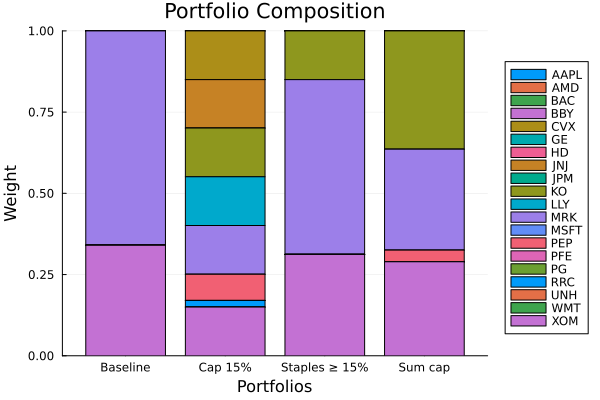

In [8]:
results = [res_base, res_cap, res_groupsum, res_sum]
labels = ["Baseline", "Cap 15%", "Staples ≥ 15%", "Sum cap"]

pretty_table(DataFrame(["Asset" => rd.nx,
                        [labels[i] => results[i].w for i in eachindex(results)]...]);
             formatters = [resfmt], title = "Asset weights under each constraint")

plot_stacked_bar_composition(results, rd; xticks = (1:length(labels), labels))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*